## SARIMA Model - Time Series Analysis (Series 1)
### Objective
This notebook analyzes the time series of Flu (grip) cases (15+ years, Barcelona city) using the Box-Jenkins methodology, including model fitting, validation and forecasting, using weekly data in period: 2012-2024


### Methodology
1. Exploratory analysis
2. Stationarity analysis
3. Model identification
4. Model estimation
5. Validation
6. Forecasting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels
import statsmodels.api as sm
import skforecast
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from skforecast.datasets import fetch_dataset
from skforecast.plot import set_dark_theme, plot_prediction_intervals
from skforecast.stats import Sarimax, Arima
from skforecast.recursive import ForecasterStats
from skforecast.utils import expand_index
from skforecast.model_selection import TimeSeriesFold, backtesting_stats, grid_search_stats

warnings.filterwarnings('once')
warnings.filterwarnings('ignore', category=DeprecationWarning)

COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 
COLOR_PINK = '#f4a7b9'  
COLOR_GREEN = '#0b6623' 

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

### Data Filtering

Is it selected the subset corresponding to:
- Diagnosis: Grip
- Region: Barcelona Ciutat
- Age group: 15+

In [2]:
df_serie = df[
    (df["nom_regio"] == "Barcelona Ciutat") &
    (df["diagnostic"] == "Grip") &
    (df["edat_bin"] == "15+")
    ]

serie = (
    df_serie.groupby("date")["taxa_setmanal"]
    .sum()
    .sort_index()
)
serie = serie.asfreq("W-MON")

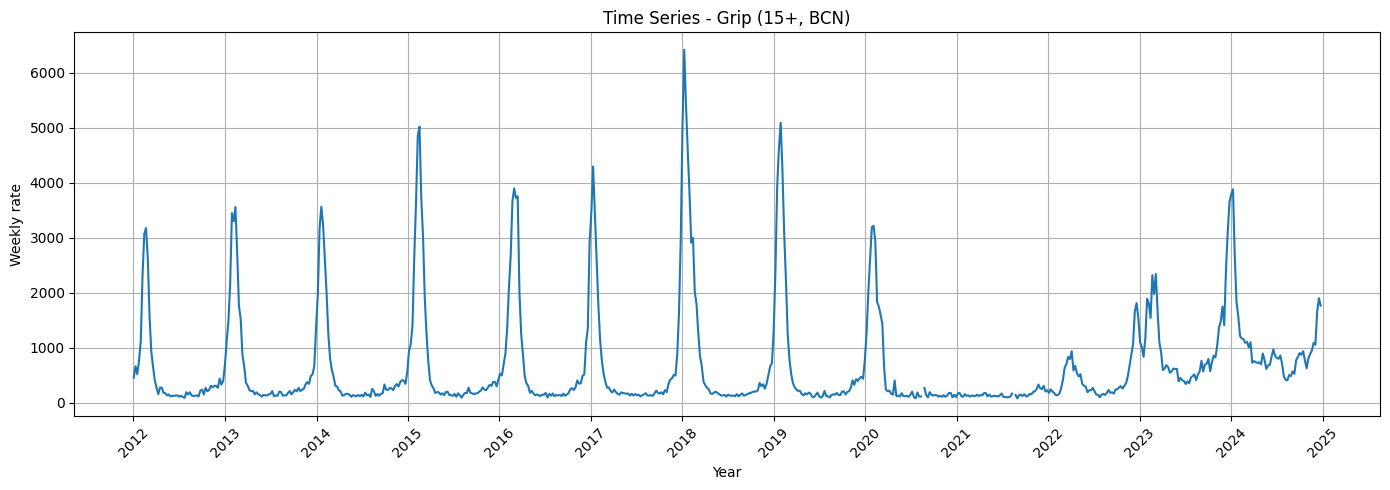

In [3]:
plt.figure(figsize=(14,5))
plt.plot(serie.index, serie.values)

plt.title("Time Series - Grip (15+, BCN)")
plt.ylabel("Weekly rate")
plt.xlabel("Year")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Train-Test Split

The dataset is split into:
- Training set: used for model estimation (2012-2019)
- Test set: used for validation and forecasting performance (2020-2024)

In [4]:
serie_1 = serie.copy()

train = serie_1[serie_1.index < "2020-01-01"]
test  = serie_1[serie_1.index >= "2020-01-01"]

train = train.interpolate()
test = test.interpolate()

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


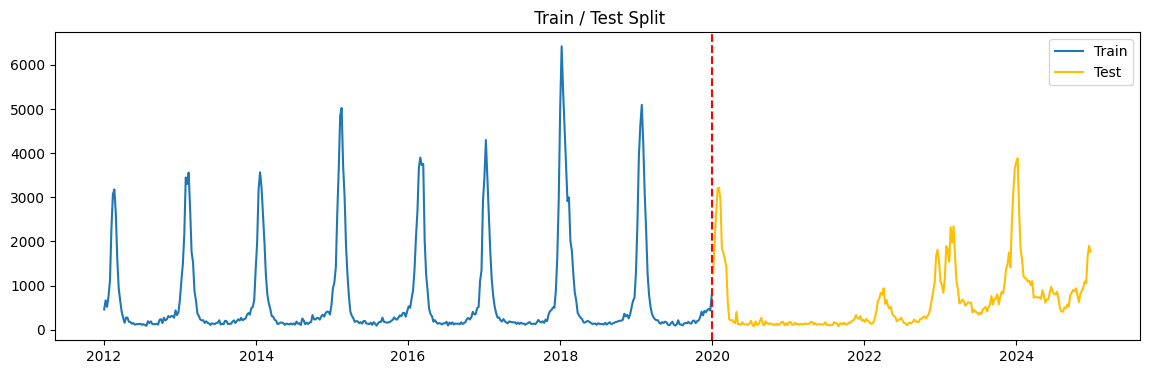

In [5]:
print(train.index.min(), train.index.max())
print(test.index.min(), test.index.max())

plt.figure(figsize=(14,4))

plt.plot(train, label="Train", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train.index.max(), color="red", linestyle="--")

plt.legend()
plt.title(" Train / Test Split")
plt.show()

### Exploratory Analysis

The original time series shows:

- a very strong annual seasonal pattern,
- pronounced epidemic peaks recurring each year,
- and changes in variability depending on the level of the series.

In particular, years with higher incidence tend to display larger fluctuations, suggesting that the variance may not be stable in the original scale. For this reason, a variance-stabilizing transformation is considered before modeling.

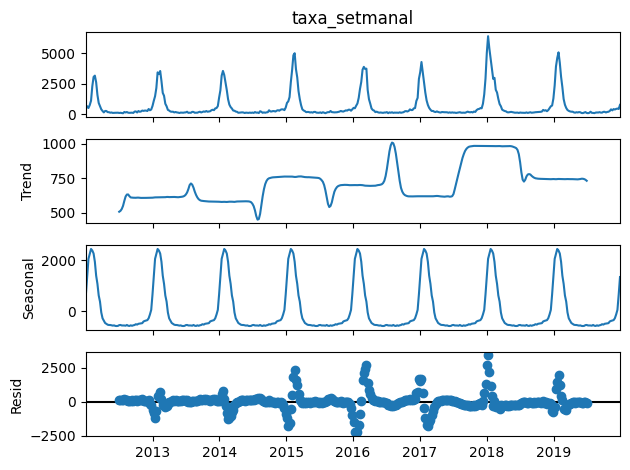

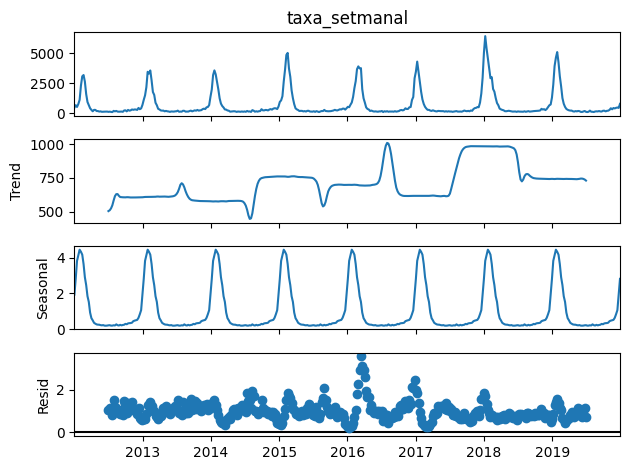

In [6]:
decomp = seasonal_decompose(train, model="additive", period=52)
decomp.plot()
plt.show()

decompm = seasonal_decompose(train, model="multiplicative", period=52)
decompm.plot()
plt.show()

Global mean (train): 686.9091016273319
Global variance (train): 1183896.2579264757

 Mean per year:
date
2012-12-31    507.288211
2013-12-31    637.395861
2014-12-31    556.079307
2015-12-31    749.084448
2016-12-31    788.935149
2017-12-31    619.561558
2018-12-31    910.160603
2019-12-31    725.928625
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variance per year:
date
2012-12-31    5.244344e+05
2013-12-31    8.059521e+05
2014-12-31    7.291890e+05
2015-12-31    1.466850e+06
2016-12-31    1.165860e+06
2017-12-31    9.620598e+05
2018-12-31    2.296626e+06
2019-12-31    1.547799e+06
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


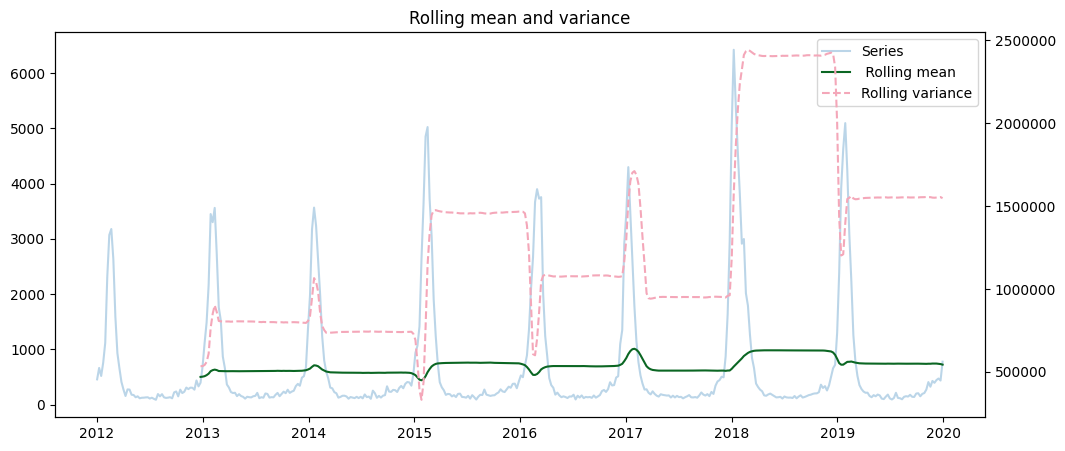

In [7]:
print("Global mean (train):", train.mean())
print("Global variance (train):", train.var())

yearly_mean = train.resample('YE').mean()
yearly_var = train.resample('YE').var()

print("\n Mean per year:")
print(yearly_mean)

print("\nVariance per year:")
print(yearly_var)

rolling_mean = train.rolling(52).mean()
rolling_var = train.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train, alpha=0.3, label='Series')
l2, = ax1.plot(rolling_mean, label=' Rolling mean', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_var, linestyle='--', label='Rolling variance', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title("Rolling mean and variance")
plt.show()

### Log Transformation

Because the variance in the original scale appears to increase with the level of the series, a logarithmic transformation was considered.

After transformation, the variability becomes more homogeneous over time, and the annual variance is substantially more stable than in the original scale. For this reason, the log-transformed series was taken as the main basis for the analysis.

The original (non-log) version was also explored, since the choice was not completely clear at the beginning. However, SARIMA models fitted on the original scale systematically produced poorer residual diagnostics, with remaining autocorrelation, heteroskedasticity, and excessively wide prediction intervals. Therefore, the final modeling strategy was carried out on the log-transformed series.

2012-01-02 00:00:00 2019-12-30 00:00:00
2020-01-06 00:00:00 2024-12-23 00:00:00


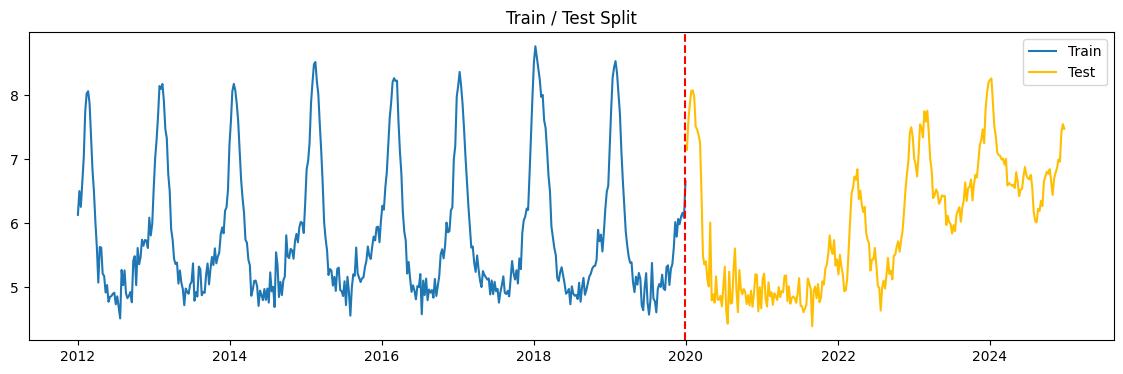

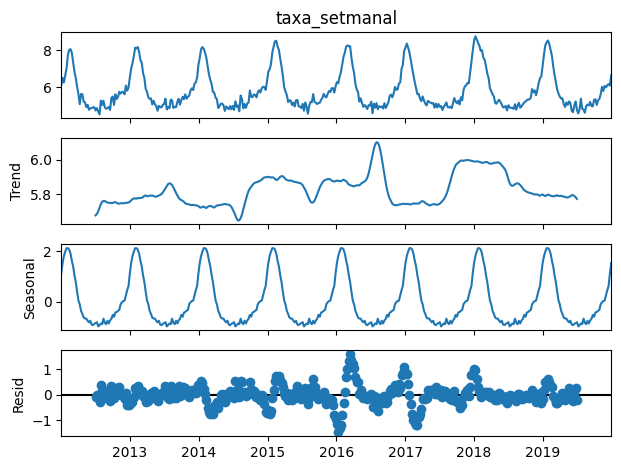

Global mean (train_log): 5.809758827482673
Global variance (train_log): 1.107689038078148

 Mean per year:
date
2012-12-31    5.688893
2013-12-31    5.828385
2014-12-31    5.701847
2015-12-31    5.857590
2016-12-31    5.970716
2017-12-31    5.740529
2018-12-31    5.923326
2019-12-31    5.766923
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64

Variance per year:
date
2012-12-31    0.850172
2013-12-31    1.030377
2014-12-31    0.924484
2015-12-31    1.171465
2016-12-31    1.258357
2017-12-31    1.032225
2018-12-31    1.436086
2019-12-31    1.232674
Freq: YE-DEC, Name: taxa_setmanal, dtype: float64


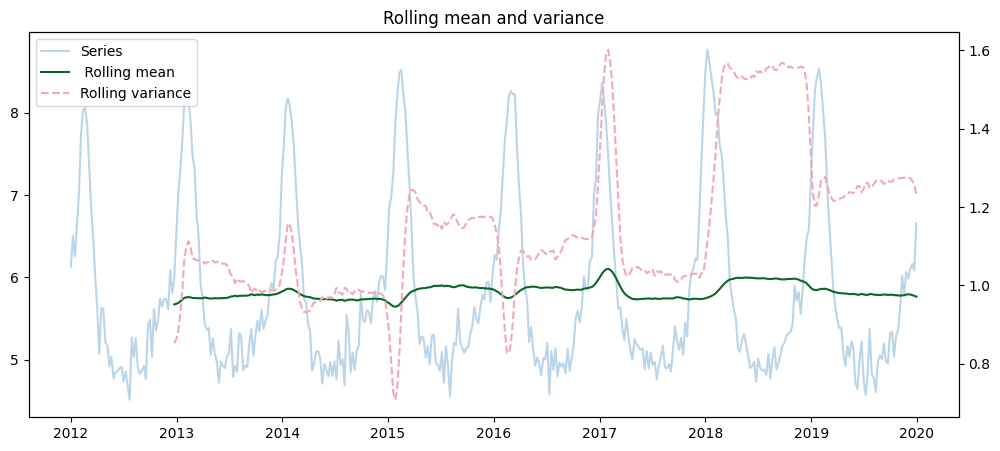

In [8]:
train_log = np.log1p(train)
test_log = np.log1p(test)

print(train_log.index.min(), train_log.index.max())
print(test_log.index.min(), test_log.index.max())

plt.figure(figsize=(14,4))

plt.plot(train_log, label="Train", color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test_log, label="Test", color=COLOR_OBS, linewidth=1.5)

plt.axvline(train_log.index.max(), color="red", linestyle="--")

plt.legend()
plt.title("Train / Test Split")
plt.show()

decomp_log = seasonal_decompose(train_log, model="additive", period=52)
decomp_log.plot()
plt.show()

print("Global mean (train_log):", train_log.mean())
print("Global variance (train_log):", train_log.var())

yearly_mean = train_log.resample('YE').mean()
yearly_var = train_log.resample('YE').var()

print("\n Mean per year:")
print(yearly_mean)

print("\nVariance per year:")
print(yearly_var)

rolling_meanlog = train_log.rolling(52).mean()
rolling_varlog = train_log.rolling(52).var()

fig, ax1 = plt.subplots(figsize=(12,5))
l1, = ax1.plot(train_log, alpha=0.3, label='Series')
l2, = ax1.plot(rolling_meanlog, label=' Rolling mean', color=COLOR_GREEN, linewidth=1.5)

ax2 = ax1.twinx()
l3, = ax2.plot(rolling_varlog, linestyle='--', label='Rolling variance', color=COLOR_PINK, linewidth=1.5)
ax2.ticklabel_format(style='plain', axis='y')

lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels)

plt.title("Rolling mean and variance")
plt.show()

### Original ACF

After the decomposition, the ACF of the original series is examined to assess the possible presence of seasonality.

Significant peaks at seasonal lags, particularly around (m = 52), suggest a clear annual seasonal pattern. This provides an initial indication that seasonal differencing may be needed.

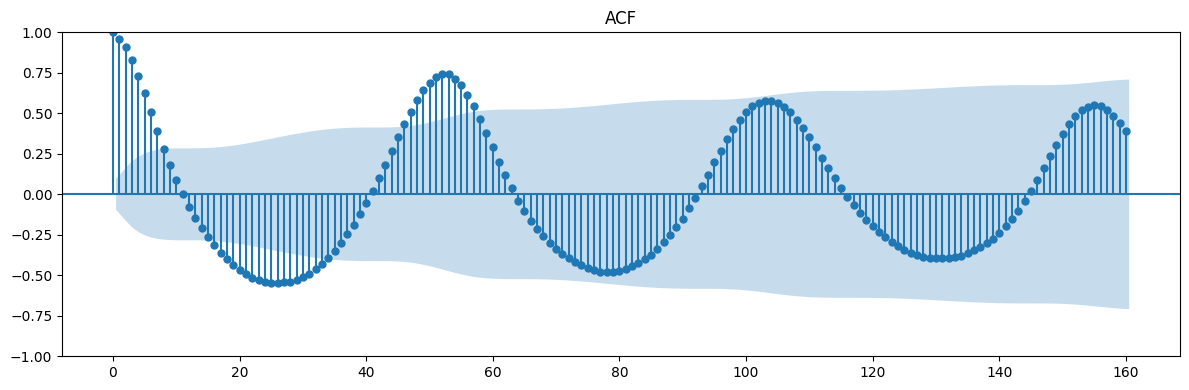

In [9]:
fig, ax = plt.subplots(figsize=(12, 4)) 
plot_acf(train_log, lags=160, ax=ax)

ax.set_title("ACF")
plt.tight_layout()
plt.show()

### Stationarity Analysis

The following statistical tests are applied:

- Augmented Dickey-Fuller (ADF)
- KPSS test

### Interpretation

- ADF: H0 = non-stationary
- KPSS: H0 = stationary


Results on the log-transformed series:

- ADF test: the null hypothesis of non-stationarity is rejected.
- KPSS test: the null hypothesis of stationarity is not rejected.

Taken together, both tests suggest that the log-transformed series is already stationary in the non-seasonal sense. Therefore, there is no strong evidence supporting the need for regular differencing at this stage.

In [10]:
dftest = adfuller(train_log, autolag = 'AIC')

print("1. ADF : ",dftest[0])
print("P-Value : ", dftest[1])

stat, p_value, lags, crit = kpss(train_log, regression='c', nlags='auto')

print("\n2. KPSS :", stat)
print("P-value:", p_value)

1. ADF :  -6.3601307333233335
P-Value :  2.486249429206904e-08

2. KPSS : 0.02124056640676763
P-value: 0.1


/var/folders/gl/4q3h26mn17x5r3shw8dj8t280000gn/T/ipykernel_97463/886079660.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, crit = kpss(train_log, regression='c', nlags='auto')


### Descriptive Analysis

To complement the statistical tests, the rolling mean and rolling variance were examined on the log-transformed series.

The rolling mean remains relatively stable over time, although some moderate changes in level can still be observed across years. More importantly, the annual variance becomes much more stable after the logarithmic transformation, fluctuating within a narrower range than in the original scale.

Similarly, the rolling variance no longer shows the strong instability observed in the original series, indicating that the log transformation successfully reduces heteroscedasticity. Although the variance is not perfectly constant, the dependence between the level of the series and its variability is substantially mitigated.

Overall, these results support the use of the logarithmic transformation and suggest that the main remaining source of non-stationarity is the strong seasonal structure rather than a non-seasonal trend.

### Seasonal Differencing Check

To further assess whether seasonal differencing is appropriate, the series after applying one seasonal difference, is compared with the original series, and the ACF is examined again.

After applying seasonal differencing, the annual repeating pattern is substantially attenuated, and the seasonal peaks in the ACF become notably weaker. This supports the choice of seasonal differencing of order one, D = 1.

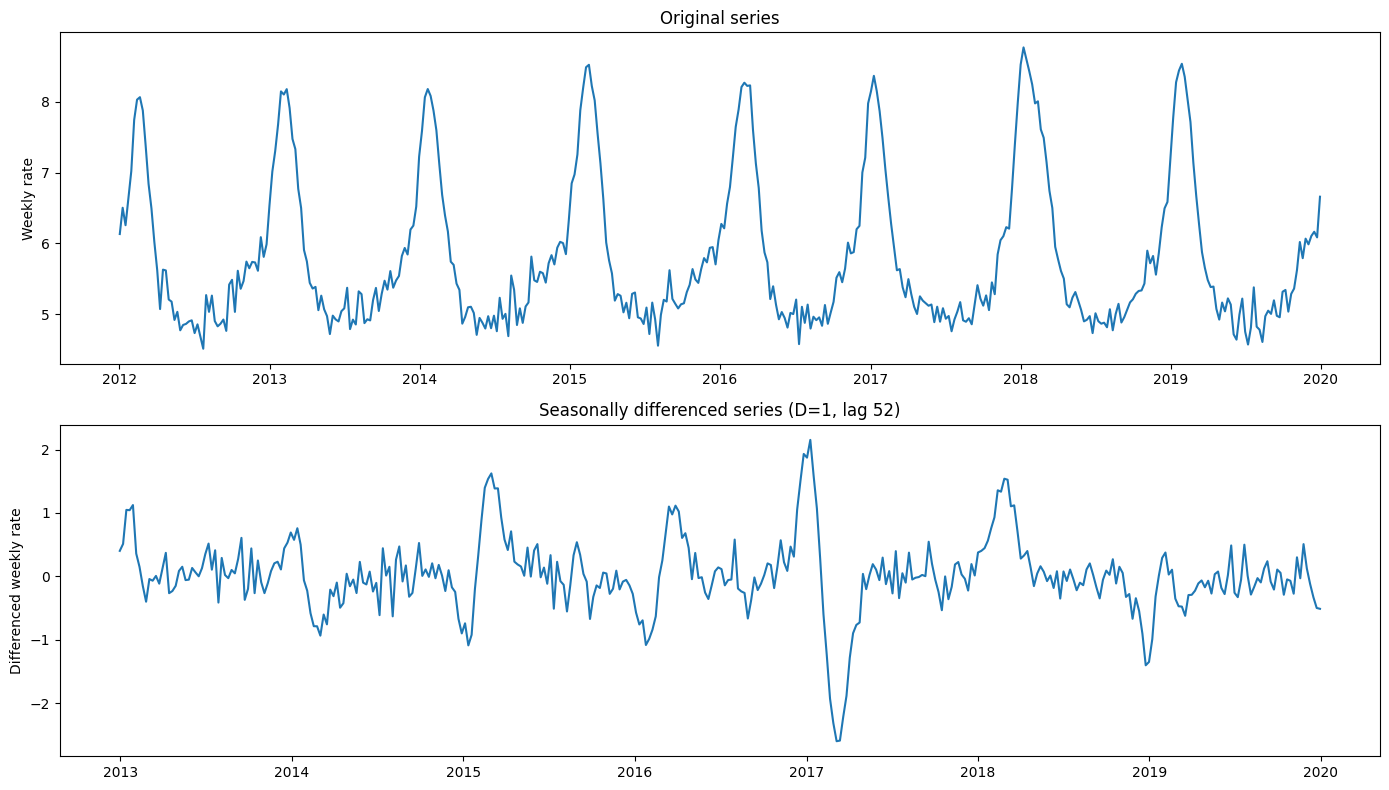

In [11]:
serie_D1 = train_log.diff(52).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(train_log)
axes[0].set_title("Original series")
axes[0].set_ylabel("Weekly rate")

axes[1].plot(serie_D1)
axes[1].set_title("Seasonally differenced series (D=1, lag 52)")
axes[1].set_ylabel("Differenced weekly rate")

plt.tight_layout()
plt.show()

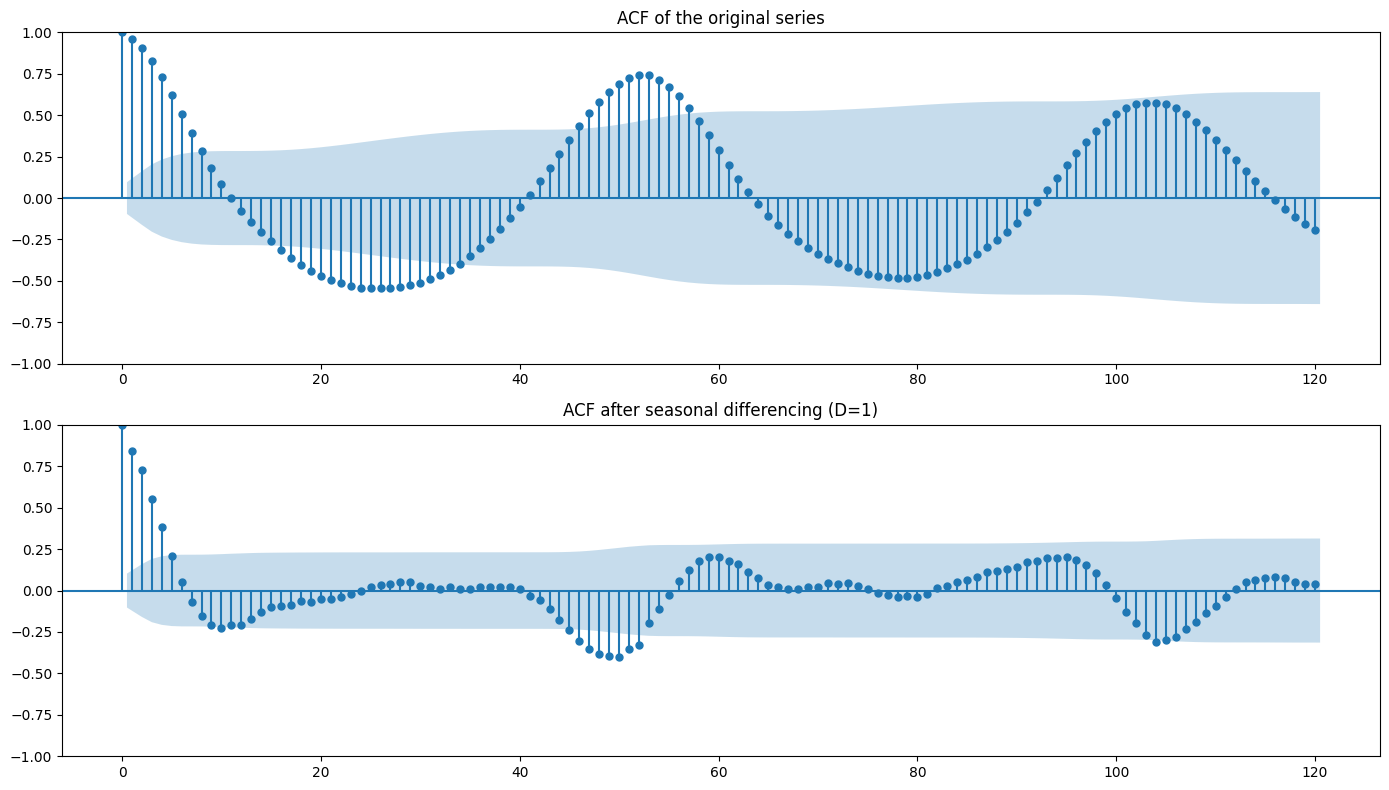

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(train_log.dropna(), lags=120, ax=axes[0])
axes[0].set_title("ACF of the original series")

plot_acf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("ACF after seasonal differencing (D=1)")

plt.tight_layout()
plt.show()

### Differencing Selection

Given the strong annual epidemic pattern, seasonal differencing was considered necessary from the beginning. The original ACF showed a very marked seasonal structure, with persistent dependence at annual lags, which supports the use of seasonal differencing.

After applying seasonal differencing only (D=1), the annual structure is substantially reduced, and the resulting series fluctuates around a more stable mean. The ACF still shows some short-term dependence, but this can be captured through the ARMA terms of the model and does not by itself justify an additional regular difference.

Moreover, when a first regular difference was also applied \(d=1, D=1\), the ACF became excessively flattened and showed a pronounced negative spike at lag 1, suggesting over-differencing.

Therefore, the final specification adopts seasonal differencing only: d = 0, D = 1.

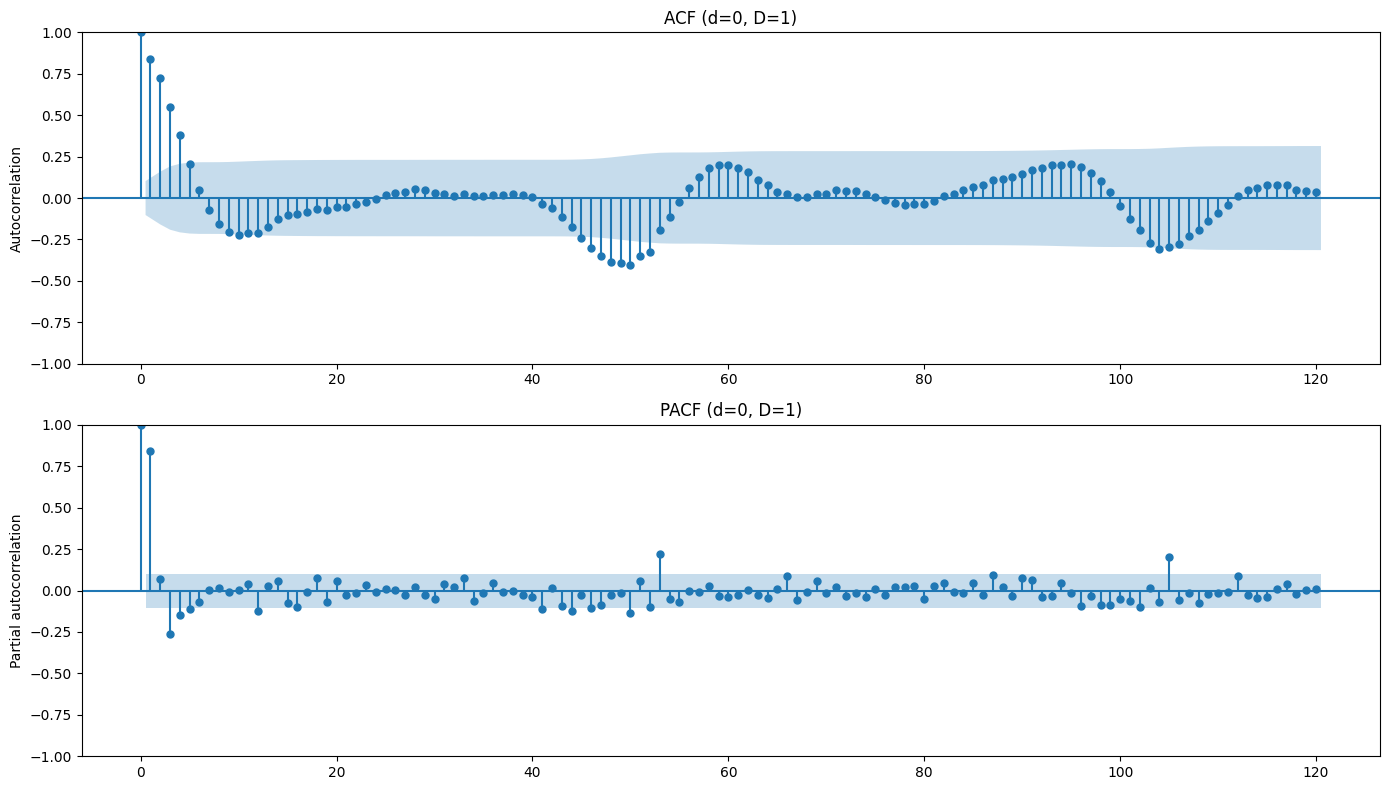

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_D1, lags=120, ax=axes[0])
axes[0].set_title("ACF (d=0, D=1)")
axes[0].set_ylabel("Autocorrelation")

plot_pacf(serie_D1, lags=120, ax=axes[1])
axes[1].set_title("PACF (d=0, D=1)")
axes[1].set_ylabel("Partial autocorrelation")

plt.tight_layout()
plt.show()

### ACF and PACF Analysis

The ACF and PACF were examined after applying the selected differencing scheme \((d=0, D=1)\) to the log-transformed series.

The ACF still shows relevant short-term persistence at the first lags, together with a remaining seasonal pattern of much smaller magnitude than in the original series. This suggests that some non-seasonal ARMA structure is still needed after seasonal differencing.

The PACF displays a strong spike at lag 1 and then quickly decreases, which supports considering low-order autoregressive terms, especially \(p=1\), and possibly \(p=2\). Since the ACF does not cut off sharply either, low-order MA terms were also considered.

Overall, the autocorrelation structure after differencing appears compatible with low-order non-seasonal ARMA components together with a seasonal MA term of order 1..

## Model Selection

Several SARIMA models were explored based on the ACF/PACF diagnostics and the seasonal structure of the series.

In practice, more specifications were considered during the exploratory phase, but the notebook reports a reduced candidate set containing the most reasonable and interpretable combinations. The focus was placed on:

- low-order non-seasonal terms \((p,q)\),
- seasonal differencing \(D=1\),
- and seasonal structures with \(Q=1\), optionally comparing \(P=0\) and \(P=1\).

The candidate models were fitted on the training period and compared mainly through AIC, while also keeping in mind model parsimony and coefficient significance.

In [14]:
models = [
    ((1,0,1), (1,1,1,52)),
    ((1,0,1), (0,1,1,52)),
    ((1,0,0), (1,1,1,52)),
    ((1,0,0), (0,1,1,52)),
    ((2,0,1), (1,1,1,52)),
    ((2,0,1), (0,1,1,52)),
    ((2,0,0), (1,1,1,52)),
    ((2,0,0), (0,1,1,52)),
    ((1,0,2), (1,1,1,52)),
    ((1,0,2), (0,1,1,52)),
    ((2,0,2), (1,1,1,52)),
    ((2,0,2), (0,1,1,52)),
    
]

best_aic = float("inf")
best_model = None

for order, seasonal_order in models:
    try:
        model = SARIMAX(
            train_log,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        results = model.fit(disp=False)
        
        print(f"Model SARIMA{order}{seasonal_order}")
        print(f"AIC: {results.aic}")
        print("-"*40)
        
        if results.aic < best_aic:
            best_aic = results.aic
            best_model = (order, seasonal_order)
    
    except:
        print(f"Error in model SARIMA{order}{seasonal_order}")

print("\n Best model:")
print(best_model)
print("AIC:", best_aic)


Model SARIMA(1, 0, 1)(1, 1, 1, 52)
AIC: 73.16741665356994
----------------------------------------
Model SARIMA(1, 0, 1)(0, 1, 1, 52)
AIC: 64.84290219203625
----------------------------------------
Model SARIMA(1, 0, 0)(1, 1, 1, 52)
AIC: 70.88914104811015
----------------------------------------
Model SARIMA(1, 0, 0)(0, 1, 1, 52)
AIC: 62.23343235712323
----------------------------------------
Model SARIMA(2, 0, 1)(1, 1, 1, 52)
AIC: 75.04671399831004
----------------------------------------


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Model SARIMA(2, 0, 1)(0, 1, 1, 52)
AIC: 65.65153925887165
----------------------------------------
Model SARIMA(2, 0, 0)(1, 1, 1, 52)
AIC: 73.09054540280545
----------------------------------------
Model SARIMA(2, 0, 0)(0, 1, 1, 52)
AIC: 64.38164100513634
----------------------------------------
Model SARIMA(1, 0, 2)(1, 1, 1, 52)
AIC: 64.14513249980934
----------------------------------------
Model SARIMA(1, 0, 2)(0, 1, 1, 52)
AIC: 52.147859819184816
----------------------------------------
Model SARIMA(2, 0, 2)(1, 1, 1, 52)
AIC: 49.36406985984296
----------------------------------------
Model SARIMA(2, 0, 2)(0, 1, 1, 52)
AIC: 41.18431197375384
----------------------------------------

 Best model:
((2, 0, 2), (0, 1, 1, 52))
AIC: 41.18431197375384


In [15]:
model1 = SARIMAX(train_log,
                order=(2,0,2),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result1 = model1.fit()
print(result1.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(2, 0, 2)x(0, 1, [1], 52)   Log Likelihood                 -14.592
Date:                              Sat, 11 Apr 2026   AIC                             41.184
Time:                                      18:33:45   BIC                             63.623
Sample:                                  01-02-2012   HQIC                            50.153
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6713      0.089     18.745      0.000       1.497       1.846
ar.L2         -0.77

In [16]:
model2 = SARIMAX(train_log,
                order=(2,0,2),
                seasonal_order=(1,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result2 = model2.fit()
print(result2.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 52)   Log Likelihood                 -17.682
Date:                              Sat, 11 Apr 2026   AIC                             49.364
Time:                                      18:33:55   BIC                             75.543
Sample:                                  01-02-2012   HQIC                            59.828
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6960      0.086     19.652      0.000       1.527       1.865
ar.L2         -0.78

In [17]:
model3 = SARIMAX(train_log,
                order=(1,0,2),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result3 = model3.fit()
print(result3.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 0, 2)x(0, 1, [1], 52)   Log Likelihood                 -21.074
Date:                              Sat, 11 Apr 2026   AIC                             52.148
Time:                                      18:33:59   BIC                             70.847
Sample:                                  01-02-2012   HQIC                            59.622
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7824      0.051     15.385      0.000       0.683       0.882
ma.L1          0.05

In [18]:
model4 = SARIMAX(train_log,
                order=(1,0,0),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False
                )

result4 = model4.fit()
print(result4.summary())

                                      SARIMAX Results                                       
Dep. Variable:                        taxa_setmanal   No. Observations:                  418
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 52)   Log Likelihood                 -28.117
Date:                              Sat, 11 Apr 2026   AIC                             62.233
Time:                                      18:34:03   BIC                             73.472
Sample:                                  01-02-2012   HQIC                            66.725
                                       - 12-30-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8447      0.029     29.188      0.000       0.788       0.901
ma.S.L52      -1.01

### Model Selection for Residual Validation

Four models were retained for a more detailed comparison:

- SARIMA(2,0,2)(0,1,1,52)
- SARIMA(2,0,2)(1,1,1,52)
- SARIMA(1,0,2)(0,1,1,52)
- SARIMA(1,0,0)(0,1,1,52)

The first three were selected because they achieved the lowest AIC values among the fitted candidates. The last one was included despite its higher AIC because of its much simpler structure, making it a useful parsimonious reference.

The final choice was therefore based not only on in-sample fit, but also on residual diagnostics, predictive performance, and parsimony.
To perform a more rigorous residual assessment, the diagnostic analysis was conducted after excluding the initial burn-in period of each fitted model. This step is justified by the state-space representation used in SARIMA estimation, where the first residuals may be affected by filter initialization and therefore may not be fully representative of the stable residual behavior of the model. For this reason, residual diagnostics were based only on the post–burn-in residuals.

Burn-in used: 107


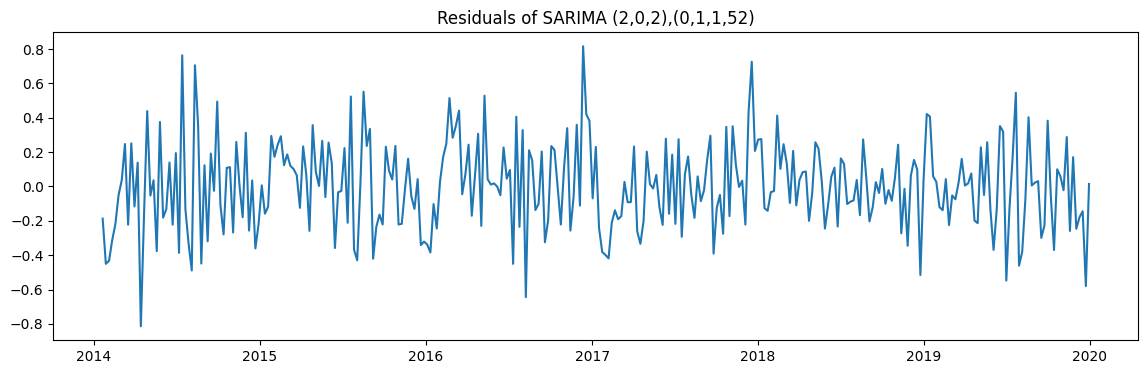

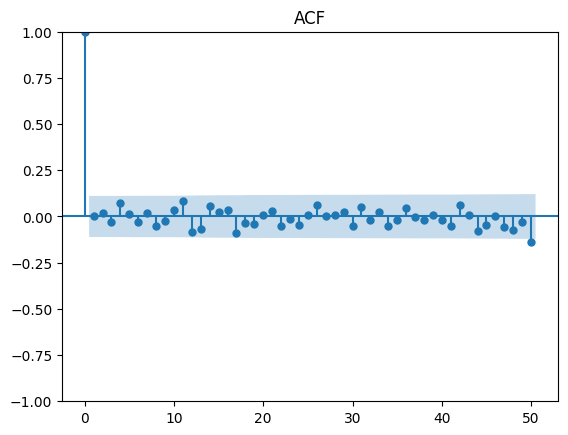


 Ljung Box
      lb_stat  lb_pvalue
10   3.938588   0.950075
20  15.360695   0.755410
30  19.630341   0.925812

Mean of residuals: 0.001068173749429341
Std of residuals: 0.2559004776798135
Relative mean (|mean| / std): 0.004174176457637785


In [19]:
residuals= result1.resid.dropna()
burn = max(result1.loglikelihood_burn, result1.filter_results.nobs_diffuse)

print(f"Burn-in used: {burn}")
residual1 = residuals.iloc[burn:].copy()


plt.figure(figsize=(14,4))
plt.plot(residual1)
plt.title("Residuals of SARIMA (2,0,2),(0,1,1,52)")
plt.show()

plot_acf(residual1, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual1, lags=[10, 20, 30], return_df=True))

mean_resid = residual1.mean()
std_resid = residual1.std()

ratio = abs(mean_resid) / std_resid

print("\nMean of residuals:", mean_resid)
print("Std of residuals:", std_resid)
print("Relative mean (|mean| / std):", ratio)

Burn-in used: 107


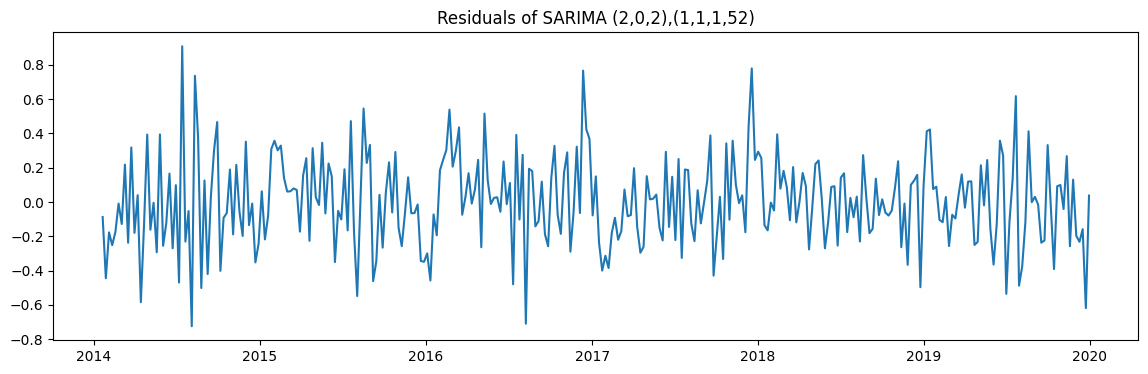

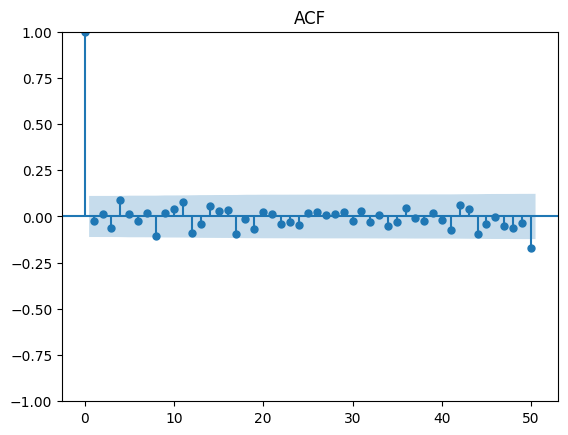


 Ljung Box
      lb_stat  lb_pvalue
10   8.666629   0.564007
20  20.496646   0.427272
30  22.961476   0.816840

Mean of residuals: 0.001530715232005652
Std of residuals: 0.25970725394562105
Relative mean (|mean| / std): 0.005894002607744494


In [20]:
residuals= result2.resid.dropna()
burn = max(result2.loglikelihood_burn, result2.filter_results.nobs_diffuse)

print(f"Burn-in used: {burn}")
residual2 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual2)
plt.title("Residuals of SARIMA (2,0,2),(1,1,1,52)")
plt.show()

plot_acf(residual2, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual2, lags=[10, 20, 30], return_df=True))

mean_resid = residual2.mean()
std_resid = residual2.std()

ratio = abs(mean_resid) / std_resid

print("\nMean of residuals:", mean_resid)
print("Std of residuals:", std_resid)
print("Relative mean (|mean| / std):", ratio)

Burn-in used: 107


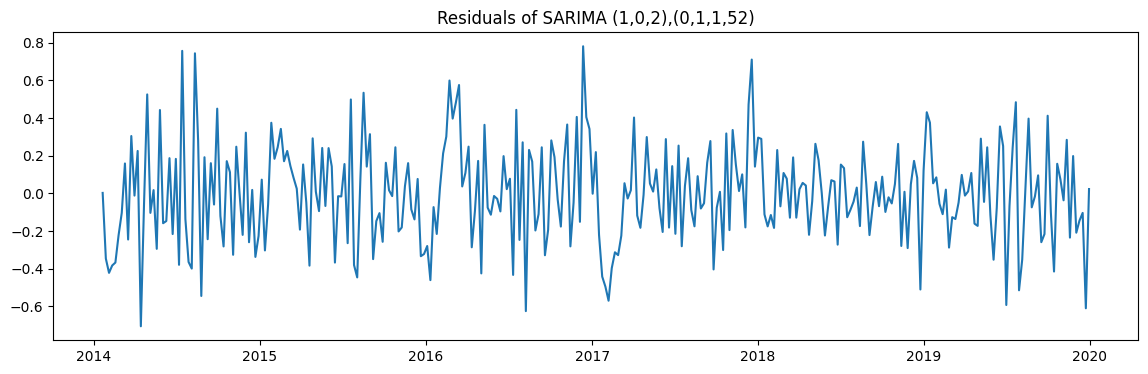

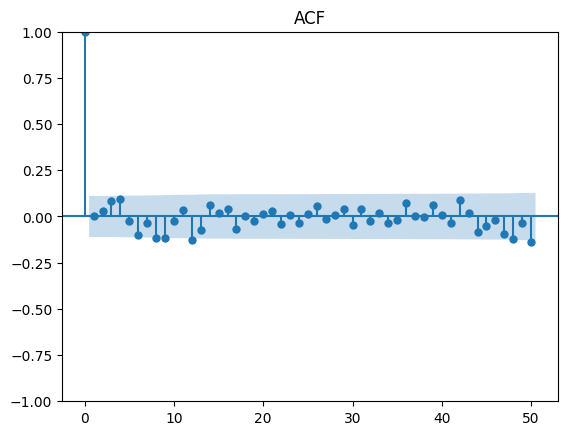


 Ljung Box
      lb_stat  lb_pvalue
10  18.191685   0.051815
20  29.187050   0.084141
30  33.146558   0.316217

Mean of residuals: -0.0018264516072886644
Std of residuals: 0.26132933155667204
Relative mean (|mean| / std): 0.006989080010303317


In [21]:
residuals= result3.resid.dropna()
burn = max(result3.loglikelihood_burn, result3.filter_results.nobs_diffuse)

print(f"Burn-in used: {burn}")
residual3 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual3)
plt.title("Residuals of SARIMA (1,0,2),(0,1,1,52)")
plt.show()

plot_acf(residual3, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual3, lags=[10, 20, 30], return_df=True))

mean_resid = residual3.mean()
std_resid = residual3.std()

ratio = abs(mean_resid) / std_resid

print("\nMean of residuals:", mean_resid)
print("Std of residuals:", std_resid)
print("Relative mean (|mean| / std):", ratio)

Burn-in used: 105


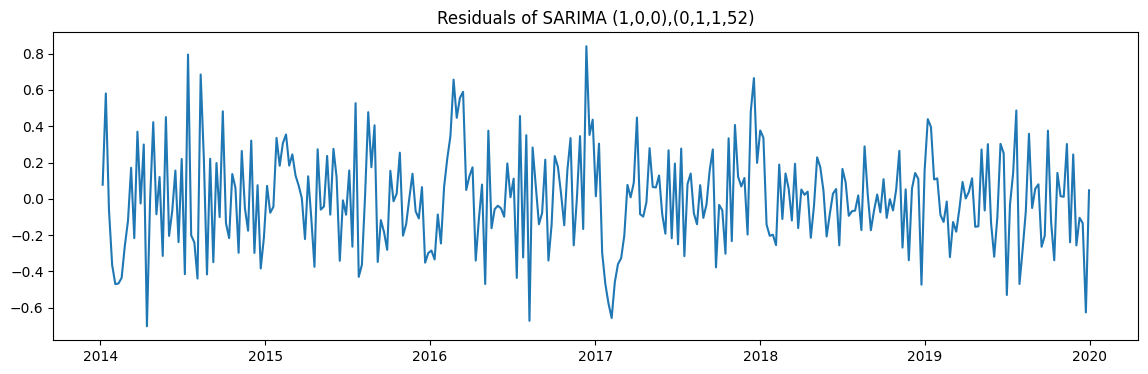

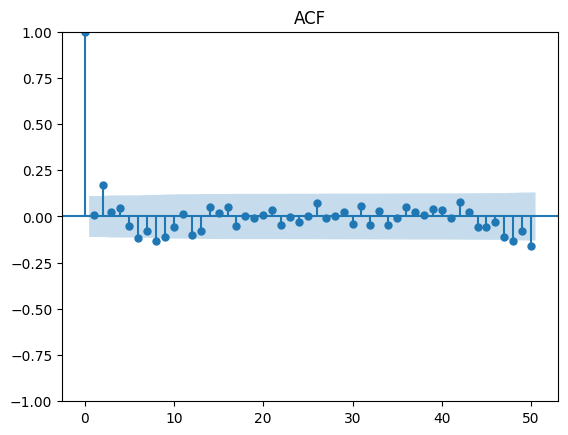


 Ljung Box
      lb_stat  lb_pvalue
10  28.256449   0.001642
20  36.339450   0.014027
30  40.383408   0.097649

Mean of residuals: 0.000513038394393047
Std of residuals: 0.26732723962048105
Relative mean (|mean| / std): 0.0019191399840936413


In [22]:
residuals= result4.resid.dropna()
burn = max(result4.loglikelihood_burn, result4.filter_results.nobs_diffuse)

print(f"Burn-in used: {burn}")
residual4 = residuals.iloc[burn:].copy()

plt.figure(figsize=(14,4))
plt.plot(residual4)
plt.title("Residuals of SARIMA (1,0,0),(0,1,1,52)")
plt.show()

plot_acf(residual4, lags=50)
plt.title("ACF")
plt.show()

print("\n Ljung Box")
print(acorr_ljungbox(residual4, lags=[10, 20, 30], return_df=True))

mean_resid = residual4.mean()
std_resid = residual4.std()

ratio = abs(mean_resid) / std_resid

print("\nMean of residuals:", mean_resid)
print("Std of residuals:", std_resid)
print("Relative mean (|mean| / std):", ratio)

### Residual Validation Results

Residuals were analysed for the four retained candidate models in order to assess their adequacy.

The SARIMA(2,0,2)(0,1,1) and SARIMA(2,0,2)(1,1,1) models showed the most satisfactory residual behaviour overall, with low residual autocorrelation and Ljung–Box results compatible with a white-noise structure. By contrast, the SARIMA(1,0,2)(0,1,1) model showed weaker residual diagnostics at short lags, while the SARIMA(1,0,0)(0,1,1) model displayed clearer evidence of remaining residual dependence and was therefore considered less adequate.


In [23]:
# Model 1
pred1 = result1.get_forecast(steps=len(test_log))
pred1_mean = pred1.predicted_mean

mae1 = mean_absolute_error(test_log, pred1_mean)
rmse1 = root_mean_squared_error(test_log, pred1_mean)

# Model 2
pred2 = result2.get_forecast(steps=len(test_log))
pred2_mean = pred2.predicted_mean

mae2 = mean_absolute_error(test_log, pred2_mean)
rmse2 = root_mean_squared_error(test_log, pred2_mean)

# Model 3
pred3 = result3.get_forecast(steps=len(test_log))
pred3_mean = pred3.predicted_mean

mae3 = mean_absolute_error(test_log, pred3_mean)
rmse3 = root_mean_squared_error(test_log, pred3_mean)


print("Model (2,0,2)(0,1,1) → MAE:", mae1, "RMSE:", rmse1)
print("Model (2,0,2)(1,1,1) → MAE:", mae2, "RMSE:", rmse2)
print("Model (1,0,2)(0,1,1) → MAE:", mae3, "RMSE:", rmse3)

Model (2,0,2)(0,1,1) → MAE: 0.8654429330605927 RMSE: 1.1091938964308345
Model (2,0,2)(1,1,1) → MAE: 0.8617657448475547 RMSE: 1.1043618072729295
Model (1,0,2)(0,1,1) → MAE: 0.8664664129150937 RMSE: 1.1073200291276597


### Final Model Selection

Although the SARIMA(2,0,2)(1,1,1) model achieved slightly lower MAE and RMSE values in the small backtesting exercise, the improvement was only marginal. In contrast, the SARIMA(2,0,2)(0,1,1) model attained a clearly lower AIC, all of its estimated coefficients were statistically significant, and its residual diagnostics were more satisfactory overall.

Therefore, the SARIMA(2,0,2)(0,1,1) model is selected as the final specification for this series, since it provides the best overall balance between goodness of fit, residual adequacy, and model interpretability.


### Forecasting
Once the model has been validated, I generate forecasts using the test set horizon.

The objective is to evaluate how well the model captures:
- the overall trend
- the seasonal pattern
- the variability of the series

Predictions are accompanied by prediction intervals, which reflect the uncertainty of the model.

In [24]:
#Final model
model = SARIMAX(train_log,
                order=(2,0,2),
                seasonal_order=(0,1,1,52),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit()

pred = result.get_forecast(steps=len(test_log))
pred_mean_log = pred.predicted_mean
pred_ci_log = pred.conf_int()

pred_mean = np.expm1(pred_mean_log)
pred_ci = np.expm1(pred_ci_log) 

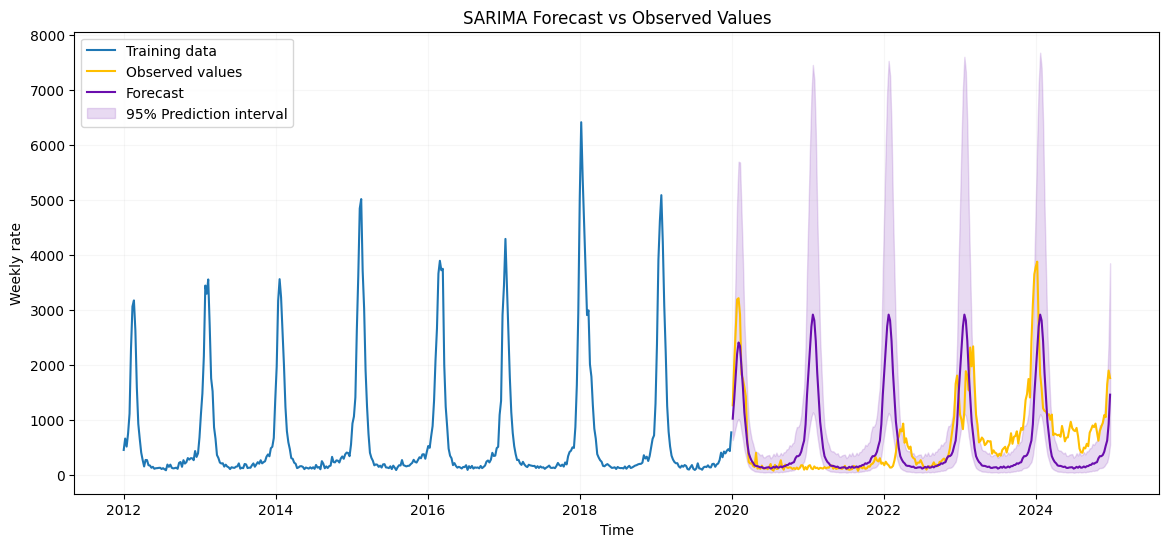

In [25]:
plt.figure(figsize=(14,6))

plt.plot(train, label='Training data', color=COLOR_TRAIN, linewidth=1.5)
plt.plot(test, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='95% Prediction interval')

plt.legend()
plt.title("SARIMA Forecast vs Observed Values")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.grid(alpha=0.1)
plt.show()

In [26]:
mae_total = mean_absolute_error(test, pred_mean)
rmse_total = root_mean_squared_error(test, pred_mean)

covTotal = ((test >= pred_ci.iloc[:, 0]) & (test <= pred_ci.iloc[:, 1])).mean()

print("TOTAL")
print("MAE:", mae_total)
print("RMSE:", rmse_total)
print("Coverage:", covTotal)

TOTAL
MAE: 503.5526703034023
RMSE: 780.2890089976131
Coverage: 0.5846153846153846


### Forecast Evaluation

To quantitatively evaluate the forecasting performance, I compute error metrics such as:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)

These metrics measure the difference between observed and predicted values, allowing me to assess the accuracy of the model.

The empirical coverage of the 95% prediction intervals is about 0.58, which is below the nominal level and suggests that forecast uncertainty is underestimated.

To further investigate this issue, the test period is divided into two subperiods:
- COVID period
- Post-COVID period

This allows me to analyze whether the model behaves differently under structural changes in the data.

In [27]:
test_covid = test["2020":"2021"]
test_post = test["2022":"2024"]

pred_covid = pred_mean["2020":"2021"]
pred_post = pred_mean["2022":"2024"]

ci_covid = pred_ci.loc["2020":"2021"]
ci_post = pred_ci.loc["2022":"2024"]

 
mae_covid = mean_absolute_error(test_covid, pred_covid)
rmse_covid = root_mean_squared_error(test_covid, pred_covid)

cov_covid = ((test_covid >= ci_covid.iloc[:, 0]) & (test_covid <= ci_covid.iloc[:, 1])).mean()

print("\nCOVID (2020-2021)")
print("MAE:", mae_covid)
print("RMSE:", rmse_covid)
print("Coverage:", cov_covid)


mae_post = mean_absolute_error(test_post, pred_post)
rmse_post = root_mean_squared_error(test_post, pred_post)

cov_post = ((test_post >= ci_post.iloc[:, 0]) & (test_post <= ci_post.iloc[:, 1])).mean()

print("\nPOST-COVID (2022-2024)")
print("MAE:", mae_post)
print("RMSE:", rmse_post)
print("Coverage:", cov_post)


COVID (2020-2021)
MAE: 337.324526572098
RMSE: 691.9585333144156
Coverage: 0.8076923076923077

POST-COVID (2022-2024)
MAE: 614.3714327909386
RMSE: 833.9946970573037
Coverage: 0.4358974358974359


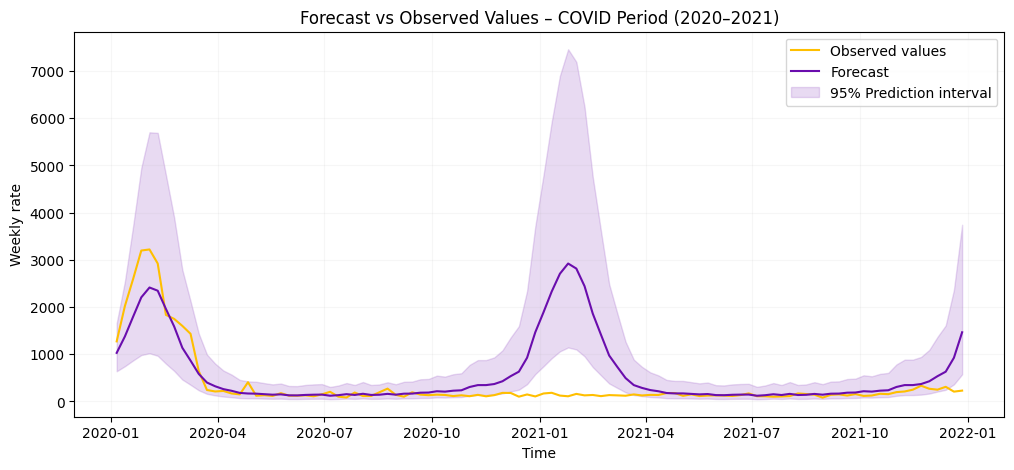

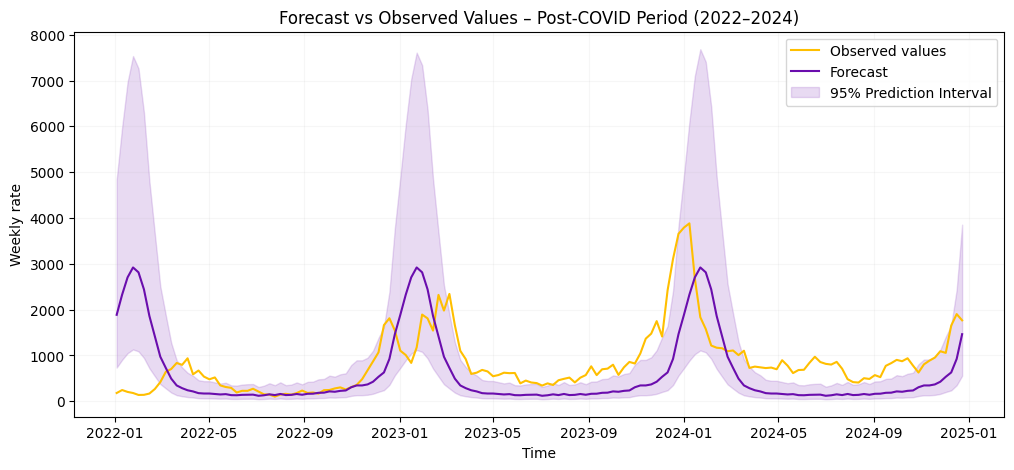

In [28]:
plt.figure(figsize=(12,5))

plt.plot(test_covid, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_covid, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_covid.index,
                 ci_covid.iloc[:, 0],
                 ci_covid.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='95% Prediction interval')

plt.title("Forecast vs Observed Values – COVID Period (2020–2021)")
plt.xlabel("Time")
plt.ylabel("Weekly rate") 
plt.legend()
plt.grid(alpha=0.1)
plt.show()


plt.figure(figsize=(12,5))

plt.plot(test_post, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_post, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.fill_between(ci_post.index,
                 ci_post.iloc[:, 0],
                 ci_post.iloc[:, 1],
                 color=COLOR_FORECAST,
                 alpha=0.15,
                 label='95% Prediction Interval')

plt.title("Forecast vs Observed Values – Post-COVID Period (2022–2024)")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.legend()
plt.grid(alpha=0.1)
plt.show()

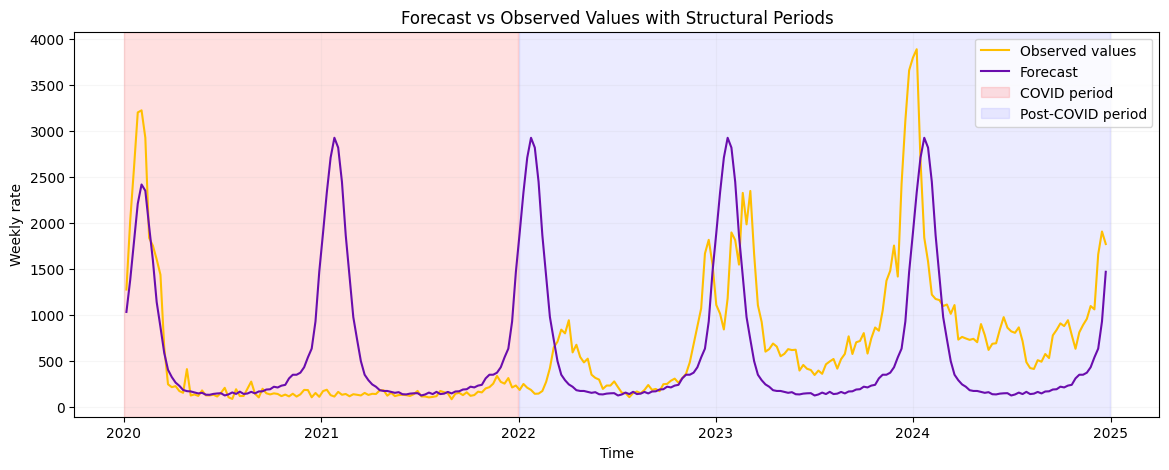

In [29]:
plt.figure(figsize=(14,5))

plt.plot(test, label='Observed values', color=COLOR_OBS, linewidth=1.5)
plt.plot(pred_mean, label='Forecast', color=COLOR_FORECAST, linewidth=1.5)

plt.axvspan(pd.to_datetime("2020-01-01"),
            pd.to_datetime("2021-12-31"),
            color='red', alpha=0.12, label='COVID period')

plt.axvspan(pd.to_datetime("2022-01-01"),
            pd.to_datetime("2024-12-31"),
            color='blue', alpha=0.08, label='Post-COVID period')

plt.legend()
plt.title("Forecast vs Observed Values with Structural Periods")
plt.xlabel("Time")
plt.ylabel("Weekly rate")
plt.grid(alpha=0.1)

plt.show()

### Visual Analysis

The model behaves differently in the COVID period (2020–2021) and in the post-COVID period (2022–2024).

During COVID, the model underestimates the large initial peak and cannot reproduce the disruption caused by the pandemic. Still, once the first shock passes, the observed series remains at relatively low levels, so the overall forecast errors are moderate and the coverage stays reasonably high.

A plausible interpretation is that the usual influenza pattern was temporarily distorted by the pandemic, due to changes in respiratory virus circulation, public health measures, and possible overlap between influenza-like cases and COVID-related diagnoses.

In the post-COVID period, the model performs worse. It still captures the broad seasonal pattern, but it fails to reproduce the new baseline level and the greater variability observed between epidemic peaks. This leads to higher forecast errors and much lower coverage.

Therefore, the results suggest that the main difficulty is not only the COVID shock itself, but also the structural change in influenza dynamics after the pandemic.